<a href="https://colab.research.google.com/github/amallindask/data-science-2026/blob/main/Pertemuan11_Amallinda_250401020003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**IDENTITAS MAHASISWA**

---

Nama: Amallinda Sekar Kinasih

---

NIM : 250401020003

---

Kelas : IF403

In [1]:
#  Langkah 1: Generate & Eksplorasi Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate dataset sintetis
np.random.seed(42)

grp1 = np.random.normal([30,20],[6,8],(100,2))
grp2 = np.random.normal([70,55],[8,10],(100,2))
grp3 = np.random.normal([110,85],[10,8],(100,2))

data = np.vstack([grp1,grp2,grp3])

df = pd.DataFrame(data, columns=['pendapatan_tahunan','skor_belanja'])

df['usia'] = np.random.randint(18,65,len(df))
df['gender'] = np.random.choice(['L','P'],len(df))

print("Shape:",df.shape)
print()

print(df.head())
print()

print(df.describe().round(2))

Shape: (300, 4)

   pendapatan_tahunan  skor_belanja  usia gender
0           32.980285     18.893886    64      P
1           33.886131     32.184239    21      P
2           28.595080     18.126904    29      L
3           39.475277     26.139478    62      L
4           27.183154     24.340480    19      L

       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


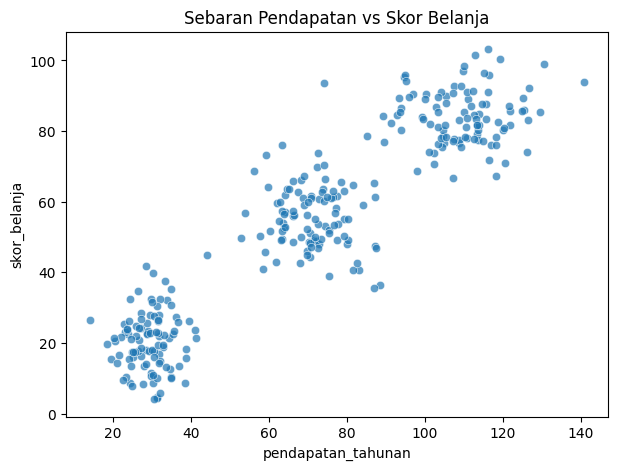

In [2]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x='pendapatan_tahunan',
    y='skor_belanja',
    alpha=0.7
)

plt.title("Sebaran Pendapatan vs Skor Belanja")
plt.show()

In [3]:
#  Langkah 2: Preprocessing Data

from sklearn.preprocessing import StandardScaler

X = df[['pendapatan_tahunan','skor_belanja']].values

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Rata-rata setelah scaling")
print(X_scaled.mean(axis=0).round(3))

print()

print("Standar deviasi setelah scaling")
print(X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling
[-0.  0.]

Standar deviasi setelah scaling
[1. 1.]


In [4]:
#   Langkah 3: Metode Elbow untuk Menentukan K

from sklearn.cluster import KMeans

wcss = []

for k in range(1,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        init='k-means++'
    )

    km.fit(X_scaled)

    wcss.append(km.inertia_)

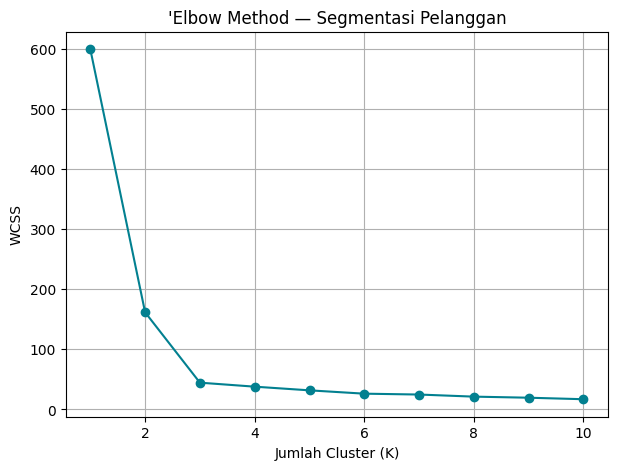

In [5]:
plt.figure(figsize=(7,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o',
    color='#028090'
)

plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("WCSS")
plt.title("'Elbow Method — Segmentasi Pelanggan")

plt.grid(True)

plt.show()

Berdasarkan grafik Elbow Method, titik siku (elbow) terlihat pada K = 3 sehingga jumlah cluster yang optimal adalah 3. Setelah titik tersebut penurunan nilai WCSS tidak lagi signifikan. Hasil ini sesuai dengan dataset yang memang dibuat memiliki tiga kelompok pelanggan.

In [6]:
#  Langkah 4: Melatih Model K-Means

from sklearn.metrics import silhouette_score

model = KMeans(
    n_clusters=3,
    random_state=42,
    init='k-means++'
)

model.fit(X_scaled)
df["cluster"] = model.labels_
print("WCSS :",model.inertia_)
print()

print("Silhouette Score :",silhouette_score(X_scaled,model.labels_))
print()

print(df.groupby("cluster")[["pendapatan_tahunan","skor_belanja"]].mean().round(2))

WCSS : 44.5564179805733

Silhouette Score : 0.6953274658286891

         pendapatan_tahunan  skor_belanja
cluster                                  
0                     70.99         55.05
1                     29.31         20.27
2                    109.20         84.08


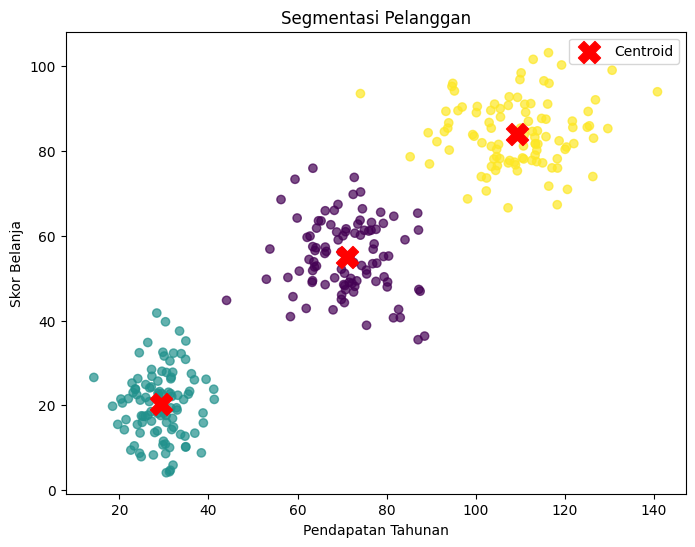

In [7]:
#  Langkah 5: Visualisasi Hasil Clustering

centroids = scaler.inverse_transform(
    model.cluster_centers_
)

plt.figure(figsize=(8,6))

plt.scatter(
    df["pendapatan_tahunan"],
    df["skor_belanja"],
    c=df["cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c="red",
    marker="X",
    s=250,
    label="Centroid"
)

plt.xlabel("Pendapatan Tahunan")

plt.ylabel("Skor Belanja")

plt.title("Segmentasi Pelanggan")

plt.legend()

plt.show()

Cluster 0 merupakan pelanggan dengan pendapatan dan skor belanja rendah sehingga dapat disebut sebagai segmen hemat.

Cluster 1 memiliki pendapatan dan skor belanja pada tingkat menengah sehingga termasuk segmen menengah.

Cluster 2 terdiri dari pelanggan dengan pendapatan dan skor belanja tinggi sehingga termasuk segmen premium. Hasil ini menunjukkan bahwa algoritma K-Means berhasil mengelompokkan pelanggan berdasarkan karakteristik yang dimiliki.

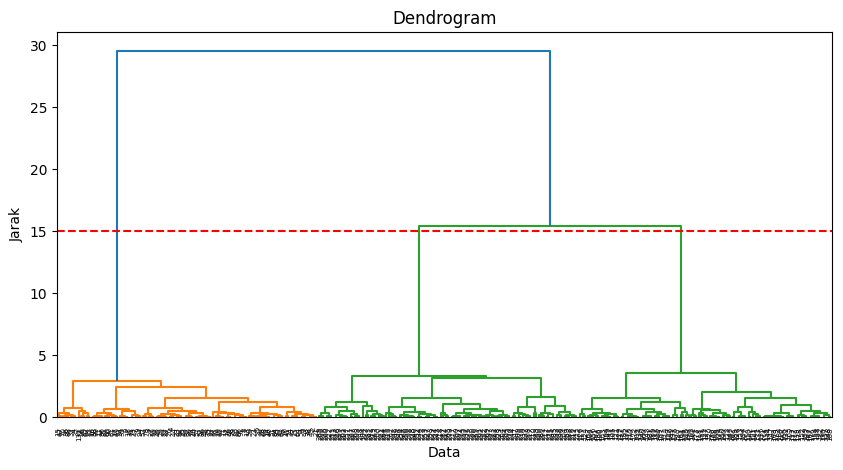

In [8]:
#  Langkah 6: Hierarchical Clustering (Pembanding)

from scipy.cluster.hierarchy import linkage,dendrogram

Z = linkage(
    X_scaled,
    method="ward"
)

plt.figure(figsize=(10,5))

dendrogram(Z)

plt.title("Dendrogram")

plt.xlabel("Data")

plt.ylabel("Jarak")

plt.axhline(
    y=15,
    color="red",
    linestyle="--"
)

plt.show()

Berdasarkan dendrogram, data juga membentuk **tiga** kelompok utama sehingga hasilnya konsisten dengan metode Elbow dan algoritma K-Means. Hal ini menunjukkan bahwa struktur data memang secara alami terbagi menjadi **tiga segmen pelanggan**.


###Keismpulan
Pada praktikum ini dilakukan segmentasi pelanggan menggunakan algoritma K-Means dengan bantuan Metode Elbow untuk menentukan jumlah cluster yang optimal. Hasil analisis menunjukkan bahwa nilai K = 3 merupakan jumlah cluster terbaik karena mampu mengelompokkan pelanggan menjadi tiga segmen, yaitu hemat, menengah, dan premium. Hasil tersebut juga didukung oleh Hierarchical Clustering yang menghasilkan jumlah cluster yang konsisten. Segmentasi ini dapat dimanfaatkan perusahaan untuk menyusun strategi pemasaran yang lebih efektif sesuai karakteristik masing-masing kelompok pelanggan.